# Cross-coupled EMT and DP Ph3 GFL state-space validation

This notebook validates EMT and DP three-phase grid-following-inverter models with nominal-frequency filter-inductor cross-coupling enabled consistently in every simulation formulation and analytical reference,

$$v^*_{\mathrm{inv},dq}=v_{\mathrm{PI},dq}+j\omega_NL_fi_{f,dq}.$$

The base case represents a weak grid (SCR 1.4). It deliberately contains two distinct stability-relevant modal families: a slow 4--6 Hz synchronization/control interaction and a fast approximately 1.2 kHz electrical interaction. The three studies validate the fine-step modal result, quantify timestep dependence of both modes, and cross three independent stability boundaries by changing one quantity at a time.

Reproduce the complete dataset with `./EMT_DP_Ph3_GFL_CrossCoupled_StateSpaceValidation --all`. The original non-cross-coupled benchmark and its output remain unchanged. The optional `--benchmark-scan` command writes exploratory diagnostics that are not used below.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

build_dir = Path('/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx')
result_dir = build_dir/'logs/EMT_DP_Ph3_GFL_CrossCoupled_StateSpaceValidation'
required = ['parameters.csv','eigenvalues.csv','summary.csv','participation.csv',
            'weak_grid_eigenvalues.csv','weak_grid_participation.csv']
missing = [name for name in required if not (result_dir/name).exists()]
if missing:
    raise FileNotFoundError(f'Missing {missing} in {result_dir}. Run the cross-coupled C++ example with --all.')
parameters = pd.read_csv(result_dir/'parameters.csv')
eigenvalues = pd.read_csv(result_dir/'eigenvalues.csv')
summary = pd.read_csv(result_dir/'summary.csv')
participation = pd.read_csv(result_dir/'participation.csv')
weak_eigenvalues = pd.read_csv(result_dir/'weak_grid_eigenvalues.csv')
weak_participation = pd.read_csv(result_dir/'weak_grid_participation.csv')
time_manifest_path = result_dir/'time_domain_manifest.csv'
weak_time_manifest_path = result_dir/'weak_grid_time_domain_manifest.csv'
time_manifest = pd.read_csv(time_manifest_path) if time_manifest_path.exists() else pd.DataFrame()
weak_time_manifest = pd.read_csv(weak_time_manifest_path) if weak_time_manifest_path.exists() else pd.DataFrame()
parameter_table = parameters.set_index('parameter')

model_order = ['analytical no delay','exact split companion','EMT variable',
               'EMT split','DP Ph3 variable','DP Ph3 split']
reference_models = {'analytical no delay','exact split companion'}
colors = dict(zip(model_order, plt.get_cmap('tab10').colors))
markers = {'analytical no delay':'x','exact split companion':'+','EMT variable':'o',
           'EMT split':'s','DP Ph3 variable':'^','DP Ph3 split':'v'}
mode_bands = {'slow synchronization':(0.5,20.0),'fast electrical':(800.0,1500.0)}

def display_numeric_table(frame, precision=4):
    shown=frame.copy(); numeric=shown.select_dtypes(include=[np.number]).columns
    shown.loc[:,numeric]=shown.loc[:,numeric].round(precision); display(shown)
def modal_method(model): return None if model in reference_models else 'one_step'
def matching_reference(model): return 'exact split companion' if 'split' in model else 'analytical no delay'
def rows_for(model,dt_us=1.0,study='time_step_sweep',method=None,gain=None):
    rows=eigenvalues[(eigenvalues.model==model)&np.isclose(eigenvalues.time_step_us,dt_us)&(eigenvalues.study==study)]
    if method is not None: rows=rows[rows.method==method]
    if gain is not None: rows=rows[np.isclose(rows.kp_power_multiplier,gain)]
    return rows
def finite_modes(rows,positive=False):
    rows=rows[np.isfinite(rows.lambda_real)&np.isfinite(rows.lambda_imag)].copy()
    return rows[rows.lambda_imag>0] if positive else rows
def band_modes(rows,band='fast electrical'):
    modes=finite_modes(rows,True); frequency=modes.lambda_imag/(2*np.pi)
    return modes[frequency.between(*mode_bands[band])]
def nearest_lambda(rows,target):
    distance=np.hypot(rows.lambda_real-target.lambda_real,rows.lambda_imag-target.lambda_imag)
    return rows.loc[distance.idxmin()]
def nearest_z(rows,target):
    distance=np.hypot(rows.z_real-target.z_real,rows.z_imag-target.z_imag)
    return rows.loc[distance.idxmin()]
def critical_reference(model,band='fast electrical',dt_us=1.0,study='time_step_sweep',gain=None):
    modes=band_modes(rows_for(model,dt_us,study,None,gain),band)
    if modes.empty: raise ValueError(f'No {band} mode for {model}, {study}, {dt_us} us')
    return modes.loc[modes.lambda_real.idxmax()]
def matched_mode(model,reference,dt_us=1.0,study='time_step_sweep',gain=None):
    if model in reference_models: return reference
    return nearest_lambda(finite_modes(rows_for(model,dt_us,study,'one_step',gain),True),reference)
def lifted_floquet_mode(model,dt_us,one_step_mode):
    modes=finite_modes(rows_for(model,dt_us,method='monodromy'))
    if modes.empty: raise ValueError(f'No Floquet modes for {model} at {dt_us} us')
    dt=dt_us*1e-6; period=1/float(parameter_table.loc['frequency','value']); steps=round(period/dt)
    if not np.isclose(steps*dt,period,rtol=0,atol=1e-12):
        raise ValueError(f'{dt_us} us does not close one fundamental period')
    one_step_z=complex(one_step_mode.z_real,one_step_mode.z_imag)
    expected=one_step_z**steps
    distance=np.abs(modes.z_real.to_numpy()+1j*modes.z_imag.to_numpy()-expected)
    row=modes.iloc[np.argmin(distance)]; multiplier=complex(row.z_real,row.z_imag)
    harmonic=round((steps*np.angle(one_step_z)-np.angle(multiplier))/(2*np.pi))
    root=abs(multiplier)**(1/steps)*np.exp(1j*(np.angle(multiplier)+2*np.pi*harmonic)/steps)
    equivalent=(2/dt)*(root-1)/(root+1) if 'variable' in model else np.log(root)/dt
    return equivalent.real,equivalent.imag/(2*np.pi),distance.min()

def state_group(name):
    name=name.lower().split('.')[-1]
    for label in ['psi','theta_pll','phi_pll','p_filtered','q_filtered','phi_d','phi_q','gamma_d','gamma_q']:
        if label==name or name.endswith(label): return 'psi' if label=='theta_pll' else label
    if 'delay' in name: return 'v_inv_delay'
    if 'u_previous' in name: return 'auxiliary interface memory'
    if 'gridinductor' in name or 'i_line' in name: return 'i_line'
    if 'vc_' in name or name.startswith('vc'): return 'v_c'
    if 'if_' in name or name.startswith('if'): return 'i_f'
    return name
def grouped_participation(model,mode,dt_us=1.0):
    all_modes=finite_modes(rows_for(model,dt_us,method=modal_method(model)))
    partner=all_modes.iloc[np.argmin(abs(all_modes.lambda_real.to_numpy()-mode.lambda_real)+abs(all_modes.lambda_imag.to_numpy()+mode.lambda_imag))]
    indices=[int(mode['index']),int(partner['index'])]
    selected=participation[(participation.study=='time_step_sweep')&(participation.model==model)&
                           np.isclose(participation.time_step_us,dt_us)&participation.mode_index.isin(indices)].copy()
    selected['group']=[state_group(name) for name in selected.state_name]
    grouped=selected.groupby('group').p_abs.sum().sort_values(ascending=False)
    return grouped/grouped.sum()
def load_case(case):
    path=Path(case.log_path); path=path if path.is_absolute() else build_dir/path
    data=pd.read_csv(path,skipinitialspace=True); time=data.iloc[:,0].to_numpy()
    pcol=next(c for c in data.columns if c=='p_inst' or c.startswith('p_inst_'))
    pref=float(parameter_table.loc['active_power_reference','value']); signal=(data[pcol].to_numpy()-pref)/abs(pref)
    keep=np.isfinite(time)&np.isfinite(signal); return time[keep],signal[keep]
def envelope_and_fit(time,signal,predicted_frequency,start,end,smoothing=.002):
    dt=np.median(np.diff(time)); samples=max(5,int(round(smoothing/dt)))
    baseband=signal*np.exp(-2j*np.pi*predicted_frequency*time)
    smooth=(pd.Series(baseband.real).rolling(samples,center=True,min_periods=samples//2).mean().to_numpy()+
            1j*pd.Series(baseband.imag).rolling(samples,center=True,min_periods=samples//2).mean().to_numpy())
    envelope=2*np.abs(smooth); phase=np.full(len(smooth),np.nan)
    valid=np.isfinite(smooth.real)&np.isfinite(smooth.imag); phase[valid]=np.unwrap(np.angle(smooth[valid]))
    fit=(time>start)&(time<end)&np.isfinite(envelope)&np.isfinite(phase)&(envelope>1e-12)
    if fit.sum()<20: return envelope,np.nan,np.nan,fit
    damping=np.polyfit(time[fit],np.log(envelope[fit]),1)[0]
    frequency=predicted_frequency+np.polyfit(time[fit],phase[fit],1)[0]/(2*np.pi)
    return envelope,damping,frequency,fit

key=['voltage_rms_ll','apparent_power_base','short_circuit_ratio','grid_x_over_r',
     'stable_kp_power_multiplier','unstable_kp_power_multiplier',
     'current_cross_coupling_coefficient','undamped_lcl_resonance_frequency']
display_numeric_table(parameters[parameters.parameter.isin(key)])


,parameter,value,unit
1,apparent_power_base,1.200000e+07,VA
2,voltage_rms_ll,3.300000e+03,V
9,short_circuit_ratio,1.400000e+00,-
10,grid_x_over_r,1.000000e+01,-
23,current_cross_coupling_coefficient,3.980000e-02,ohm
41,stable_kp_power_multiplier,2.000000e-01,-
42,unstable_kp_power_multiplier,2.600000e-01,-
51,undamped_lcl_resonance_frequency,1.159634e+03,Hz


## Study 1 — fine-step modal validation in a weak grid

**Purpose.** At $\Delta t=1\,\mu\mathrm{s}$ and the stable gain, validate both stability-relevant modal families against separately assembled no-delay and exact split-companion references. Agreement is assessed using eigenvalues and grouped participation factors, not eigenvalues alone.

The slow mode is expected to involve synchronization and outer-control states; the fast mode is expected to be an LCL/grid electrical interaction. Floquet results provide an independent EMT-periodic check after multiplier-plane mode matching.


,mode family,model/reference,matching reference,method,damping [1/s],frequency [Hz],damping error [1/s],frequency error [Hz]
0,slow synchronization,analytical no delay,—,analytical,-6.4068,5.4623,NaN,NaN
1,slow synchronization,exact split companion,—,analytical,-6.4076,5.4621,NaN,NaN
2,slow synchronization,EMT variable,analytical no delay,one_step,-6.4079,5.4622,0.0011,0.0001
3,slow synchronization,EMT split,exact split companion,one_step,-6.4070,5.4622,0.0006,0.0001
4,slow synchronization,DP Ph3 variable,analytical no delay,one_step,-6.4079,5.4622,0.0011,0.0001
5,slow synchronization,DP Ph3 split,exact split companion,one_step,-6.4073,5.4621,0.0003,0.0000
6,slow synchronization,EMT variable,analytical no delay,Floquet-equivalent,-6.4079,5.4622,0.0011,0.0001
7,slow synchronization,EMT split,exact split companion,Floquet-equivalent,-6.4317,5.4628,0.0241,0.0007
8,fast electrical,analytical no delay,—,analytical,-48.1845,1159.6068,NaN,NaN
9,fast electrical,exact split companion,—,analytical,-48.1839,1159.6017,NaN,NaN


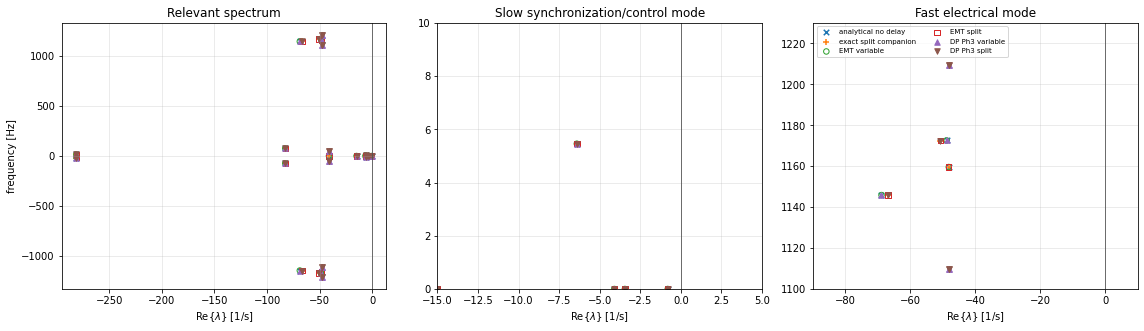

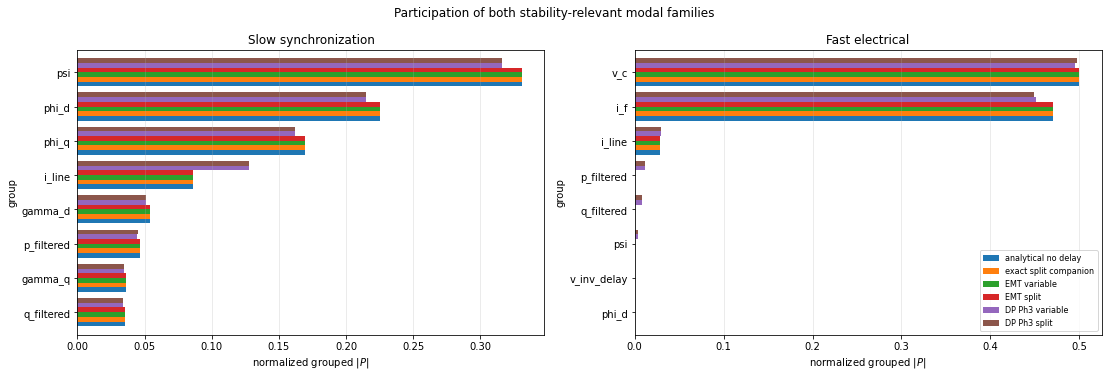

In [2]:
selected_modes={}; modal_rows=[]
for band in mode_bands:
    references={name:critical_reference(name,band) for name in reference_models}
    for model in model_order:
        reference_name=model if model in reference_models else matching_reference(model)
        reference=references[reference_name]
        mode=matched_mode(model,reference); selected_modes[(band,model)]=mode
        modal_rows.append({'mode family':band,'model/reference':model,
                           'matching reference':reference_name if model not in reference_models else '—',
                           'method':modal_method(model) or 'analytical','damping [1/s]':mode.lambda_real,
                           'frequency [Hz]':mode.lambda_imag/(2*np.pi),
                           'damping error [1/s]':abs(mode.lambda_real-reference.lambda_real) if model not in reference_models else np.nan,
                           'frequency error [Hz]':abs(mode.lambda_imag-reference.lambda_imag)/(2*np.pi) if model not in reference_models else np.nan})
    for model in ['EMT variable','EMT split']:
        reference_name=matching_reference(model); reference=references[reference_name]
        damping,frequency,_=lifted_floquet_mode(model,1.,selected_modes[(band,model)])
        modal_rows.append({'mode family':band,'model/reference':model,'matching reference':reference_name,
                           'method':'Floquet-equivalent','damping [1/s]':damping,'frequency [Hz]':frequency,
                           'damping error [1/s]':abs(damping-reference.lambda_real),
                           'frequency error [Hz]':abs(frequency-reference.lambda_imag/(2*np.pi))})
display_numeric_table(pd.DataFrame(modal_rows),precision=4)

fig,axes=plt.subplots(1,3,figsize=(16,4.7))
for model in model_order:
    modes=finite_modes(rows_for(model,method=modal_method(model)))
    physical=modes[(modes.lambda_real>-2500)&(abs(modes.lambda_imag)<2*np.pi*2500)]
    for ax in axes:
        ax.scatter(physical.lambda_real,physical.lambda_imag/(2*np.pi),marker=markers[model],s=30,
                   facecolors='none' if model in ['EMT variable','EMT split'] else None,
                   color=colors[model],label=model)
axes[0].set(title='Relevant spectrum',ylabel='frequency [Hz]')
axes[1].set(title='Slow synchronization/control mode',xlim=(-15,5),ylim=(0,10))
axes[2].set(title='Fast electrical mode',xlim=(-90,10),ylim=(1100,1230))
for ax in axes:
    ax.axvline(0,color='0.3',lw=.8); ax.grid(alpha=.3); ax.set_xlabel(r'$\mathrm{Re}\{\lambda\}$ [1/s]')
axes[2].legend(fontsize=7,ncol=2); fig.tight_layout(); plt.show()

grouped_by_band={}
for band in mode_bands:
    grouped_by_band[band]=pd.concat({m:grouped_participation(m,selected_modes[(band,m)]) for m in model_order},axis=1).fillna(0)
all_groups={band:grouped.max(axis=1).nlargest(8).index for band,grouped in grouped_by_band.items()}
fig,axes=plt.subplots(1,2,figsize=(15.5,5.3))
for ax,band in zip(axes,mode_bands):
    grouped_by_band[band].loc[all_groups[band]].iloc[::-1].plot(kind='barh',ax=ax,width=.82,
                                                               color=[colors[m] for m in model_order])
    ax.set_title(band.capitalize()); ax.set_xlabel(r'normalized grouped $|P|$'); ax.grid(axis='x',alpha=.3)
axes[0].get_legend().remove(); axes[1].legend(fontsize=8,loc='lower right')
fig.suptitle('Participation of both stability-relevant modal families'); fig.tight_layout(); plt.show()


**Study 1 claim.** At fine timestep, all extracted formulations reproduce the two analytical modal families and their dominant physical participation. EMT agreement is essentially exact; the remaining DP fast-mode offset is quantified in the table rather than treated as exact equality. The slow branch is a mixed synchronization/outer-control/grid interaction, while the fast branch is dominated by filter-capacitor voltage and filter current.

## Study 2 — timestep dependence of both modes

**Purpose.** Increase only the timestep and continuously track the slow and fast branches. Each extracted model is compared with its formulation-specific map: no delay for variable formulations and the exact split-companion map for split formulations. This separates extraction error from the actual split-delay effect.

Floquet correspondence is established in the multiplier plane. The selected one-step eigenvalue is propagated over one fundamental period, matched to the nearest monodromy multiplier, and its root nearest the one-step mode is mapped back with the same formulation-specific continuous equivalent. Only timesteps that close one fundamental period contribute a Floquet point. The overlay is restricted to the fast electrical branch, where it tests whether the EMT discrepancy is introduced by the post-extraction pole mapping. The slow split formulation has a phase-dependent delayed abc period map, so its monodromy is not expected to equal a power of one frozen step and is not overlaid.


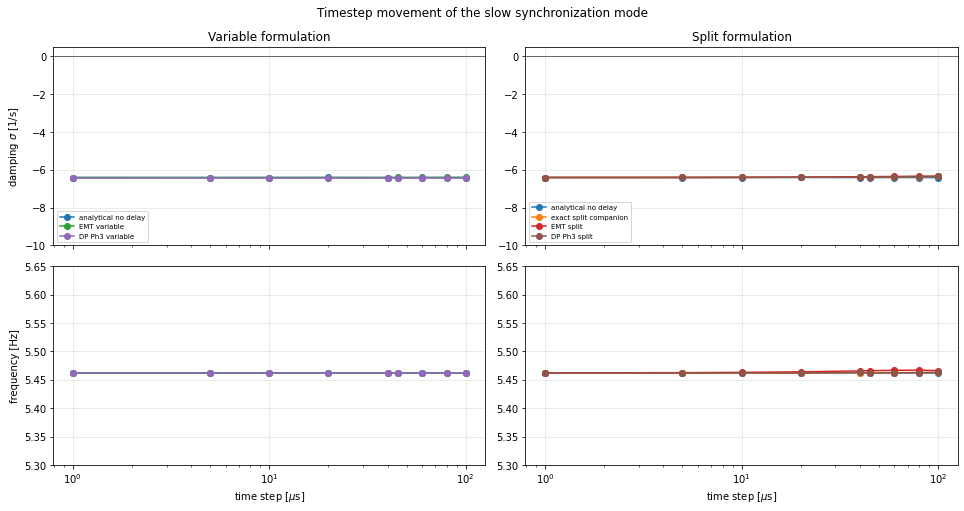

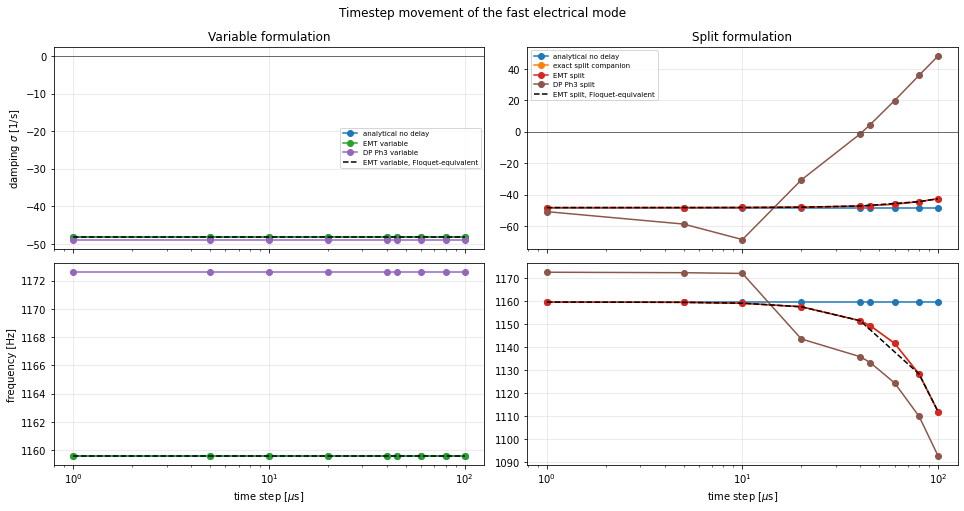

,mode family,model,maximum matching residual |Dz|,residual at 100 us
0,fast electrical,DP Ph3 split,1.510270e-02,1.510270e-02
1,fast electrical,DP Ph3 variable,7.164400e-03,7.164400e-03
2,fast electrical,EMT split,0.000000e+00,0.000000e+00
3,fast electrical,EMT variable,0.000000e+00,0.000000e+00
4,slow synchronization,DP Ph3 split,5.000000e-07,1.000000e-07
5,slow synchronization,DP Ph3 variable,3.000000e-07,3.000000e-07
6,slow synchronization,EMT split,2.800000e-06,2.400000e-06
7,slow synchronization,EMT variable,1.000000e-06,1.000000e-06


In [3]:
steps=sorted(eigenvalues.loc[(eigenvalues.study=='time_step_sweep')&(eigenvalues.time_step_us<=100.),'time_step_us'].unique())
tracked_records=[]
for band in mode_bands:
    baseline=critical_reference('analytical no delay',band)
    previous_split=critical_reference('exact split companion',band)
    for dt in steps:
        no_delay=nearest_lambda(finite_modes(rows_for('analytical no delay',dt),True),baseline)
        split_candidates=finite_modes(rows_for('exact split companion',dt),True)
        split=nearest_lambda(split_candidates,previous_split); previous_split=split
        refs={'analytical no delay':no_delay,'exact split companion':split}
        for model in model_order:
            ref=refs[model] if model in reference_models else refs[matching_reference(model)]
            mode=ref if model in reference_models else nearest_z(finite_modes(rows_for(model,dt,method='one_step'),True),ref)
            tracked_records.append({'mode family':band,'model':model,'time_step_us':dt,
                                    'damping':mode.lambda_real,'frequency_hz':mode.lambda_imag/(2*np.pi),
                                    'lambda_real':mode.lambda_real,'lambda_imag':mode.lambda_imag,
                                    'z_real':mode.z_real,'z_imag':mode.z_imag,'mode_index':int(mode['index']),
                                    'z_error':np.hypot(mode.z_real-ref.z_real,mode.z_imag-ref.z_imag),
                                    'z_from_no_delay':np.hypot(mode.z_real-no_delay.z_real,mode.z_imag-no_delay.z_imag)})
tracked=pd.DataFrame(tracked_records)
shown_steps=[1.,5.,10.,20.,40.,45.,60.,80.,100.]
shown=tracked[tracked.time_step_us.isin(shown_steps)]

for band in mode_bands:
    fig,axes=plt.subplots(2,2,figsize=(13.5,7.2),sharex='col')
    selected_band=shown[shown['mode family']==band]
    for col,formulation in enumerate(['variable','split']):
        models=['analytical no delay','EMT variable','DP Ph3 variable'] if formulation=='variable' else ['analytical no delay','exact split companion','EMT split','DP Ph3 split']
        for model in models:
            rows=selected_band[selected_band.model==model]
            axes[0,col].semilogx(rows.time_step_us,rows.damping,'o-',color=colors[model],label=model)
            axes[1,col].semilogx(rows.time_step_us,rows.frequency_hz,'o-',color=colors[model],label=model)
        axes[0,col].axhline(0,color='.3',lw=.8); axes[0,col].set_title(formulation.capitalize()+' formulation')
        # Floquet is used for its intended fast-mode post-processing check.
        # The slow EMT-split period map is phase dependent, so its monodromy
        # is not the power of one frozen step and is not overlaid here.
        emt='EMT variable' if formulation=='variable' else 'EMT split'; floquet=[]
        if band=='fast electrical':
            for dt in shown_steps:
                rows=selected_band[(selected_band.model==emt)&np.isclose(selected_band.time_step_us,dt)]
                if rows.empty: continue
                try:
                    damping,frequency,error=lifted_floquet_mode(emt,dt,rows.iloc[0]); floquet.append((dt,damping,frequency,error))
                except ValueError: pass
            if floquet:
                f=np.asarray(floquet); axes[0,col].semilogx(f[:,0],f[:,1],'k--',label=f'{emt}, Floquet-equivalent')
                axes[1,col].semilogx(f[:,0],f[:,2],'k--',label=f'{emt}, Floquet-equivalent')
        axes[0,col].legend(fontsize=7); [ax.grid(alpha=.3) for ax in axes[:,col]]
    axes[0,0].set_ylabel(r'damping $\sigma$ [1/s]'); axes[1,0].set_ylabel('frequency [Hz]')
    [ax.set_xlabel(r'time step [$\mu$s]') for ax in axes[1]]
    if band=='slow synchronization':
        # Common, deliberately wider limits show that the one-step curves are
        # practically coincident without concealing the coarse split-Floquet drift.
        for col in range(2):
            axes[0,col].set_ylim(-10.,.5)
            axes[1,col].set_ylim(5.30,5.65)
    fig.suptitle(f'Timestep movement of the {band} mode'); fig.tight_layout(); plt.show()

residual=[]
for (band,model),rows in tracked[~tracked.model.isin(reference_models)].groupby(['mode family','model']):
    residual.append({'mode family':band,'model':model,'maximum matching residual |Dz|':rows.z_error.max(),
                     'residual at 100 us':rows.loc[np.isclose(rows.time_step_us,100.),'z_error'].iloc[0]})
display_numeric_table(pd.DataFrame(residual),precision=7)


**Study 2 claim.** Both one-step extracted modal families follow their formulation-specific references as timestep increases. The slow weak-grid mode is nearly timestep-insensitive over the tested range. The fast mode exposes the expected formulation distinction: variable models remain close to the no-delay branch, whereas the split delay moves the fast branch and creates a finite timestep stability boundary. Fast-mode Floquet results corroborate the EMT one-step result and show that its difference from the analytical branch is already present in the discrete period map, rather than being created by the subsequent continuous-pole transformation.

## Study 3 — three one-parameter paths to instability

**Purpose.** Demonstrate three distinct stability transitions while changing one quantity at a time:

1. increasing only $K_{p,P}$ destabilizes the fast electrical mode;
2. increasing only the split-model timestep destabilizes the fast electrical mode through delay;
3. decreasing only SCR destabilizes the slow synchronization/control interaction.

Analytical and extracted predictions are compared at each boundary. Grouped participation identifies the mechanism, and small-signal time-domain responses independently check the predicted growth or decay.


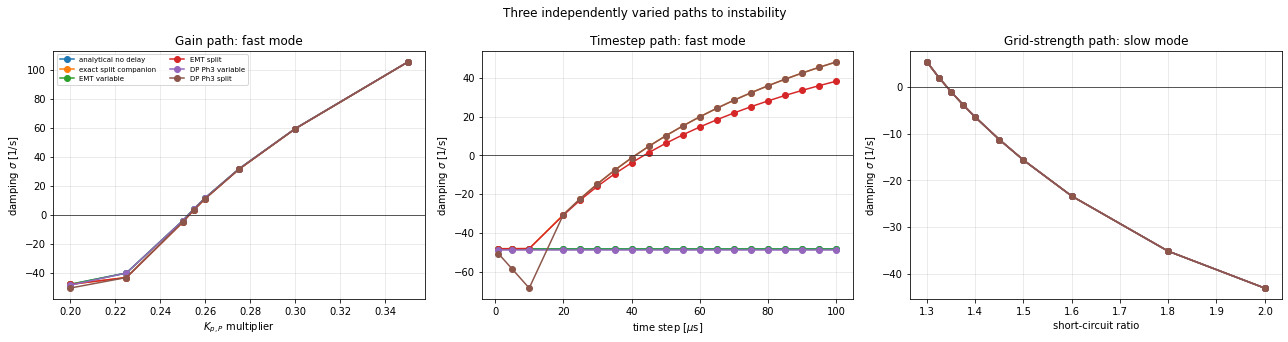

,path,model/reference,bracket 1,bracket 2,linear crossing estimate
0,"increase Kp,P (fast)",DP Ph3 split,0.250,0.255,0.2531
1,"increase Kp,P (fast)",DP Ph3 variable,0.250,0.255,0.2526
2,"increase Kp,P (fast)",EMT split,0.250,0.255,0.2531
3,"increase Kp,P (fast)",EMT variable,0.250,0.255,0.2526
4,"increase Kp,P (fast)",analytical no delay,0.250,0.255,0.2526
5,"increase Kp,P (fast)",exact split companion,0.250,0.255,0.2531
6,increase timestep (fast),DP Ph3 split,40.000,45.000,41.0902
7,increase timestep (fast),EMT split,40.000,45.000,43.6442
8,increase timestep (fast),exact split companion,40.000,45.000,41.0903
9,decrease SCR (slow),DP Ph3 split,1.325,1.350,1.3418


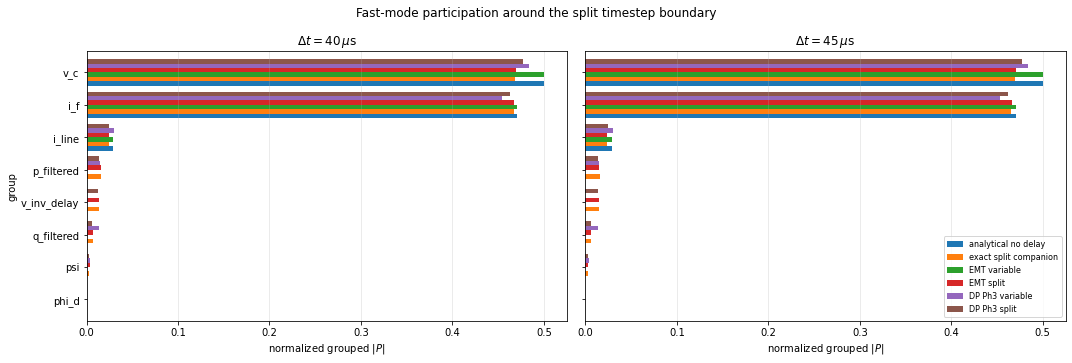

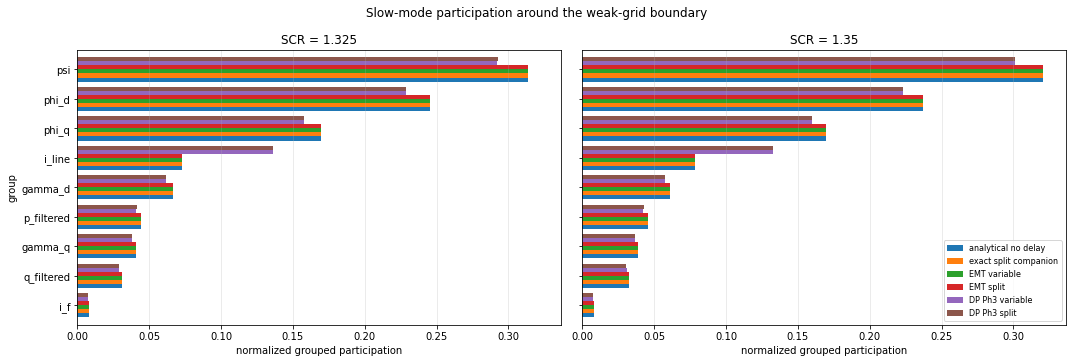

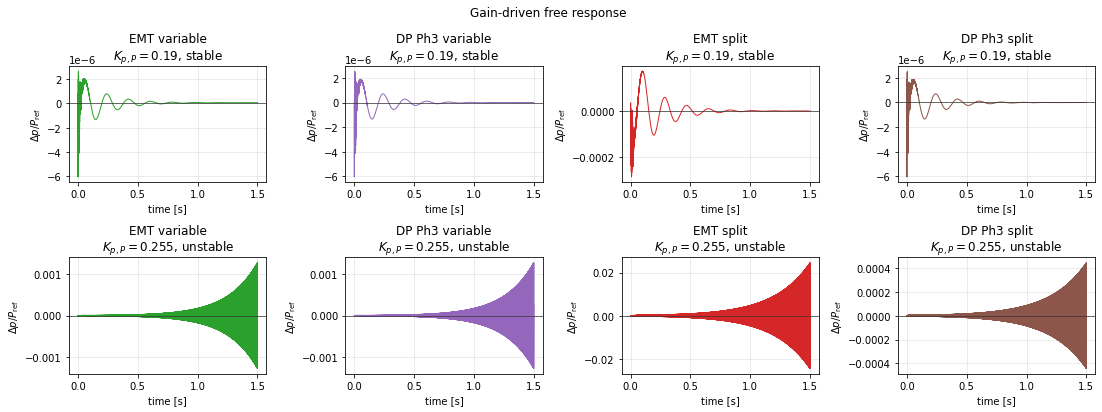

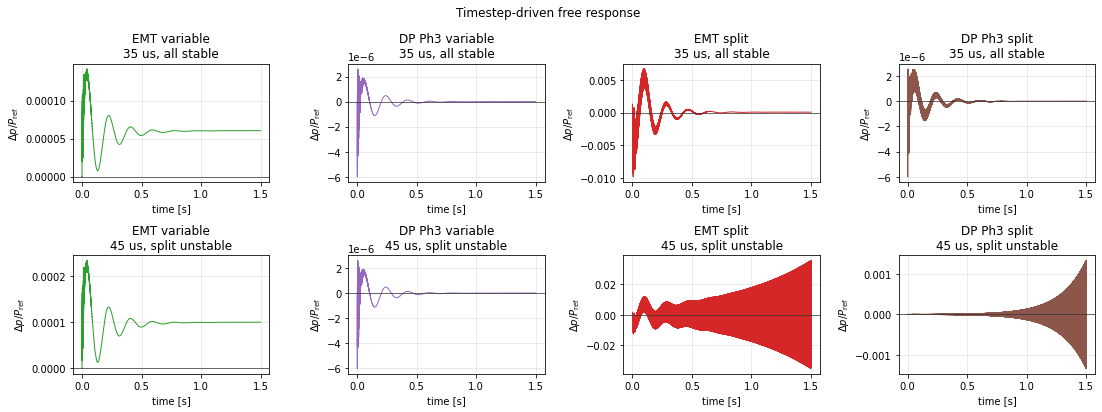

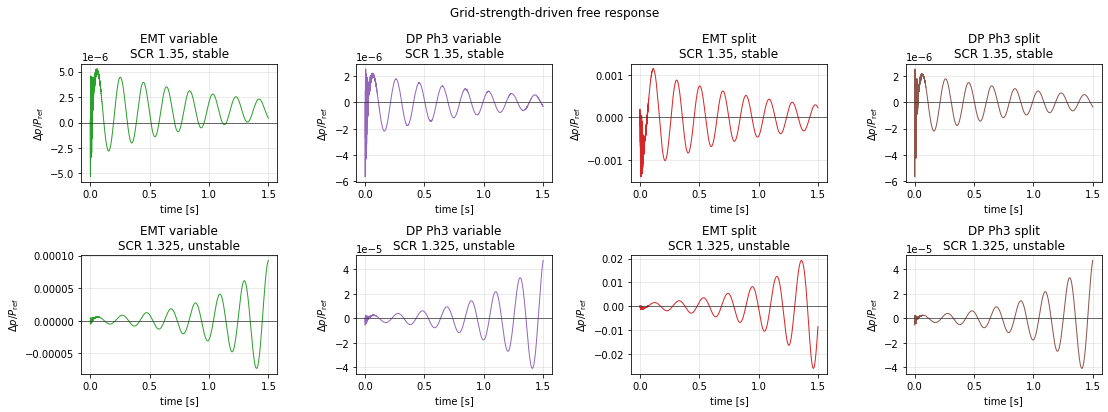

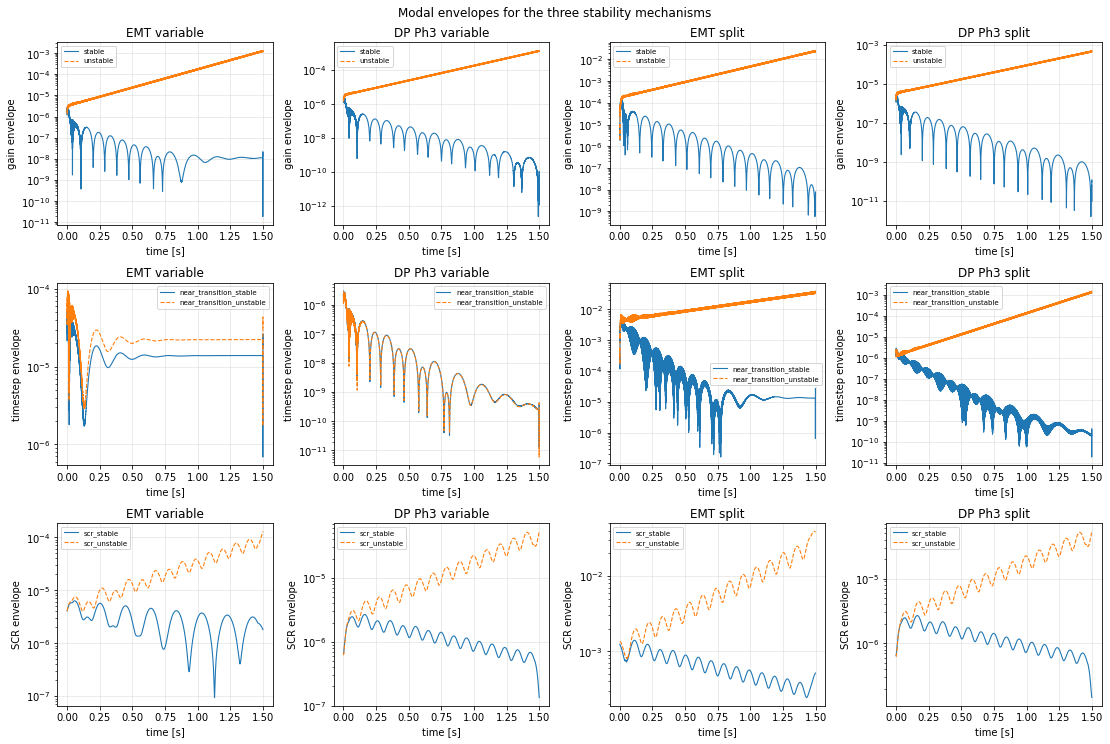

,mechanism,case,model,extracted damping [1/s],fitted damping [1/s],extracted frequency [Hz],fitted frequency [Hz],fit accepted
0,gain,stable,EMT variable,-48.185,-18.577,1159.607,454.388,False
1,gain,unstable,EMT variable,3.983,3.983,1162.137,1162.132,True
2,gain,stable,DP Ph3 variable,-48.185,-23.031,1109.607,523.185,False
3,gain,unstable,DP Ph3 variable,3.993,3.993,1162.137,1162.131,True
4,gain,stable,EMT split,-48.184,-17.764,1159.602,584.662,False
5,gain,unstable,EMT split,3.290,3.292,1161.652,1161.652,True
6,gain,stable,DP Ph3 split,-48.184,-16.987,1209.601,437.433,False
7,gain,unstable,DP Ph3 split,3.283,3.284,1161.651,1161.651,True
8,timestep,near_transition_stable,EMT variable,-48.185,0.124,1159.607,0.002,False
9,timestep,near_transition_unstable,EMT variable,-48.185,0.121,1159.607,0.000,False


Rejected single-mode fits are shown transparently but are not used as validation evidence:


,mechanism,case,model
0,gain,stable,EMT variable
2,gain,stable,DP Ph3 variable
4,gain,stable,EMT split
6,gain,stable,DP Ph3 split
8,timestep,near_transition_stable,EMT variable
9,timestep,near_transition_unstable,EMT variable
10,timestep,near_transition_stable,DP Ph3 variable
11,timestep,near_transition_unstable,DP Ph3 variable
12,timestep,near_transition_stable,EMT split
14,timestep,near_transition_stable,DP Ph3 split


In [4]:
# Three modal paths. Restrict the gain-up path to the base gain and above so that it
# follows only the intended fast branch; a separate low-gain slow crossing is not conflated with it.
gain_records=[]
gains=sorted(g for g in eigenvalues.loc[eigenvalues.study=='kp_power_sweep','kp_power_multiplier'].unique() if g>=.2-1e-12)
for gain in gains:
    refs={name:critical_reference(name,'fast electrical',study='kp_power_sweep',gain=gain) for name in reference_models}
    for model in model_order:
        ref=refs[model] if model in reference_models else refs[matching_reference(model)]
        mode=matched_mode(model,ref,study='kp_power_sweep',gain=gain)
        gain_records.append({'model':model,'gain':gain,'damping':mode.lambda_real,'frequency_hz':mode.lambda_imag/(2*np.pi)})
gain_sweep=pd.DataFrame(gain_records)

# Study 3 follows the least-damped fast branch at every timestep. This is
# intentionally distinct from Study 2 continuation: close branches can exchange
# criticality, and the stability prediction must follow the one that crosses.
timestep_records=[]
for dt in steps:
    refs={name:critical_reference(name,'fast electrical',dt_us=dt) for name in reference_models}
    for model in model_order:
        ref=refs[model] if model in reference_models else refs[matching_reference(model)]
        mode=ref if model in reference_models else nearest_z(finite_modes(rows_for(model,dt,method='one_step'),True),ref)
        timestep_records.append({'model':model,'time_step_us':dt,'damping':mode.lambda_real,
                                 'frequency_hz':mode.lambda_imag/(2*np.pi),'mode_index':int(mode['index'])})
critical_timestep=pd.DataFrame(timestep_records)

weak_positive=weak_eigenvalues[weak_eigenvalues.lambda_imag>0].copy()
weak_positive['frequency_hz']=weak_positive.lambda_imag/(2*np.pi)
weak_slow=weak_positive[weak_positive.frequency_hz.between(*mode_bands['slow synchronization'])]
weak_critical=weak_slow.loc[weak_slow.groupby(['short_circuit_ratio','model']).lambda_real.idxmax()].copy()

fig,axes=plt.subplots(1,3,figsize=(18,4.8))
for model in model_order:
    rows=gain_sweep[gain_sweep.model==model]; axes[0].plot(rows.gain,rows.damping,'o-',color=colors[model],label=model)
    rows=critical_timestep[critical_timestep.model==model]; axes[1].plot(rows.time_step_us,rows.damping,'o-',color=colors[model],label=model)
    rows=weak_critical[weak_critical.model==model].sort_values('short_circuit_ratio')
    axes[2].plot(rows.short_circuit_ratio,rows.lambda_real,'o-',color=colors[model],label=model)
axes[0].set(title=r'Gain path: fast mode',xlabel=r'$K_{p,P}$ multiplier',ylabel=r'damping $\sigma$ [1/s]')
axes[1].set(title='Timestep path: fast mode',xlabel=r'time step [$\mu$s]',ylabel=r'damping $\sigma$ [1/s]')
axes[2].set(title='Grid-strength path: slow mode',xlabel='short-circuit ratio',ylabel=r'damping $\sigma$ [1/s]')
for ax in axes: ax.axhline(0,color='.2',lw=.8); ax.grid(alpha=.3)
axes[0].legend(fontsize=7,ncol=2); fig.suptitle('Three independently varied paths to instability'); fig.tight_layout(); plt.show()

def crossing_table(data,value,damping,direction,path):
    records=[]
    for model,rows in data.groupby('model'):
        rows=rows.sort_values(value).reset_index(drop=True)
        if direction=='up': transition=rows[(rows[damping].shift(1)<0)&(rows[damping]>=0)]
        else: transition=rows[(rows[damping].shift(1)>=0)&(rows[damping]<0)]
        if transition.empty: continue
        hi=transition.index[0]; lo=hi-1
        x0,y0=rows.loc[lo,[value,damping]]; x1,y1=rows.loc[hi,[value,damping]]
        records.append({'path':path,'model/reference':model,'bracket 1':x0,'bracket 2':x1,
                        'linear crossing estimate':x0-y0*(x1-x0)/(y1-y0)})
    return records
thresholds=[]
thresholds += crossing_table(gain_sweep,'gain','damping','up','increase Kp,P (fast)')
thresholds += crossing_table(critical_timestep,'time_step_us','damping','up','increase timestep (fast)')
thresholds += crossing_table(weak_critical,'short_circuit_ratio','lambda_real','down','decrease SCR (slow)')
display_numeric_table(pd.DataFrame(thresholds),precision=4)

# Participation on both sides of the numerical fast-mode boundary.
participation_by_dt={}
for dt in [40.,45.]:
    grouped_at_dt={}
    for model in model_order:
        selected=critical_timestep[(critical_timestep.model==model)&np.isclose(critical_timestep.time_step_us,dt)].iloc[0]
        mode_rows=rows_for(model,dt,method=modal_method(model))
        mode=mode_rows[mode_rows['index']==selected.mode_index].iloc[0]
        grouped_at_dt[model]=grouped_participation(model,mode,dt)
    participation_by_dt[dt]=pd.concat(grouped_at_dt,axis=1).fillna(0)
groups=pd.concat(participation_by_dt.values(),axis=1).max(axis=1).nlargest(8).index
fig,axes=plt.subplots(1,2,figsize=(15,5.1),sharex=True,sharey=True)
for ax,dt in zip(axes,[40.,45.]):
    participation_by_dt[dt].loc[groups].iloc[::-1].plot(kind='barh',ax=ax,width=.82,color=[colors[m] for m in model_order])
    ax.set_title(rf'$\Delta t={dt:g}\,\mu$s'); ax.set_xlabel(r'normalized grouped $|P|$'); ax.grid(axis='x',alpha=.3)
axes[0].get_legend().remove(); axes[1].legend(fontsize=8,loc='lower right')
fig.suptitle('Fast-mode participation around the split timestep boundary'); fig.tight_layout(); plt.show()

# Participation on both sides of the physical slow-mode boundary.
weak_grouped={}
for scr in [1.325,1.35]:
    selected=weak_participation[np.isclose(weak_participation.short_circuit_ratio,scr)].copy()
    selected['group']=[state_group(name) for name in selected.state_name]
    grouped=selected.groupby(['model','group']).p_normalized.sum().unstack(0).fillna(0).reindex(columns=model_order)
    weak_grouped[scr]=grouped/grouped.sum(axis=0)
groups=pd.concat(weak_grouped.values(),axis=1).max(axis=1).nlargest(9).index
fig,axes=plt.subplots(1,2,figsize=(15,5.1),sharex=True,sharey=True)
for ax,scr in zip(axes,[1.325,1.35]):
    weak_grouped[scr].loc[groups].iloc[::-1].plot(kind='barh',ax=ax,width=.82,color=[colors[m] for m in model_order])
    ax.set_title(f'SCR = {scr:g}'); ax.set_xlabel('normalized grouped participation'); ax.grid(axis='x',alpha=.3)
axes[0].get_legend().remove(); axes[1].legend(fontsize=8,loc='lower right')
fig.suptitle('Slow-mode participation around the weak-grid boundary'); fig.tight_layout(); plt.show()

plotted=['EMT variable','DP Ph3 variable','EMT split','DP Ph3 split']
def plot_response_grid(manifest,cases,title):
    fig,axes=plt.subplots(2,4,figsize=(15.5,5.8),sharex='row')
    for row,(case_name,label) in enumerate(cases):
        for col,model in enumerate(plotted):
            selected=manifest[(manifest.stability_case==case_name)&(manifest.model==model)]
            for case in selected.itertuples():
                time,signal=load_case(case); axes[row,col].plot(time,signal,color=colors[model],lw=1)
            axes[row,col].axhline(0,color='.2',lw=.7); axes[row,col].grid(alpha=.3)
            axes[row,col].set(title=f'{model}\n{label}',xlabel='time [s]',ylabel=r'$\Delta p/P_{\mathrm{ref}}$')
    fig.suptitle(title); fig.tight_layout(); plt.show()

fit_records=[]
if time_manifest.empty or weak_time_manifest.empty:
    print('Time-domain data are incomplete. Run the cross-coupled executable with --all, then rerun this notebook.')
else:
    plot_response_grid(time_manifest[time_manifest.time_step_us==1.],
                       [('stable',r'$K_{p,P}=0.19$, stable'),
                        ('unstable',r'$K_{p,P}=0.255$, unstable')],
                       'Gain-driven free response')
    plot_response_grid(time_manifest[time_manifest.stability_case.str.startswith('near_transition')],
                       [('near_transition_stable','35 us, all stable'),
                        ('near_transition_unstable','45 us, split unstable')],
                       'Timestep-driven free response')
    plot_response_grid(weak_time_manifest,[('scr_stable','SCR 1.35, stable'),('scr_unstable','SCR 1.325, unstable')],
                       'Grid-strength-driven free response')

    fig,axes=plt.subplots(3,4,figsize=(15.5,10.5),sharex='row')
    mechanisms=[('gain',time_manifest[time_manifest.time_step_us==1.],[('stable','-'),('unstable','--')]),
                ('timestep',time_manifest[time_manifest.stability_case.str.startswith('near_transition')],
                 [('near_transition_stable','-'),('near_transition_unstable','--')]),
                ('SCR',weak_time_manifest,[('scr_stable','-'),('scr_unstable','--')])]
    for row,(mechanism,manifest,cases) in enumerate(mechanisms):
        for col,model in enumerate(plotted):
            ax=axes[row,col]
            for case_name,style in cases:
                selected=manifest[(manifest.stability_case==case_name)&(manifest.model==model)]
                if selected.empty: continue
                case=next(selected.itertuples()); time,signal=load_case(case)
                if mechanism=='gain':
                    candidates=band_modes(rows_for(model,1.,'kp_power_sweep','one_step',case.kp_power_multiplier),
                                          'fast electrical')
                    predicted=candidates.loc[candidates.lambda_real.idxmax()]
                    if case_name=='stable':
                        start,end=.004,min(time.max()-.02,.09)
                    else:
                        start,end=.2,min(time.max()-.05,1.2)
                    smoothing=.002
                    extracted_damping=predicted.lambda_real; extracted_frequency=predicted.lambda_imag/(2*np.pi)
                elif mechanism=='timestep':
                    dt=float(case.time_step_us)
                    predicted=critical_timestep[(critical_timestep.model==model)&np.isclose(critical_timestep.time_step_us,dt)].iloc[0]
                    start,end,smoothing=.015,time.max()-.015,.002
                    extracted_damping=predicted.damping; extracted_frequency=predicted.frequency_hz
                else:
                    scr=float(case.short_circuit_ratio)
                    predicted=weak_critical[(weak_critical.model==model)&np.isclose(weak_critical.short_circuit_ratio,scr)].iloc[0]
                    # Once a stable trace has decayed into the numerical floor,
                    # extending its fit window degrades the frequency estimate.
                    fit_stop=.9 if case_name=='scr_stable' else 1.4
                    start,end,smoothing=.2,min(fit_stop,time.max()-.05),.08
                    extracted_damping=predicted.lambda_real; extracted_frequency=predicted.frequency_hz
                envelope,damping,frequency,fit=envelope_and_fit(time,signal,extracted_frequency,start,end,smoothing)
                ax.semilogy(time,envelope,style,lw=1.1,label=case_name)
                accepted=(abs(frequency-extracted_frequency)<max(1.,.02*extracted_frequency) and
                          abs(damping-extracted_damping)<max(2.,.3*abs(extracted_damping)))
                fit_records.append({'mechanism':mechanism,'case':case_name,'model':model,
                                    'extracted damping [1/s]':extracted_damping,'fitted damping [1/s]':damping,
                                    'extracted frequency [Hz]':extracted_frequency,'fitted frequency [Hz]':frequency,
                                    'fit accepted':accepted})
            ax.grid(alpha=.3); ax.legend(fontsize=7); ax.set(title=model,xlabel='time [s]',ylabel=f'{mechanism} envelope')
    fig.suptitle('Modal envelopes for the three stability mechanisms'); fig.tight_layout(); plt.show()
    fit_table=pd.DataFrame(fit_records); display_numeric_table(fit_table,precision=3)
    rejected=fit_table[~fit_table['fit accepted']]
    if not rejected.empty:
        print('Rejected single-mode fits are shown transparently but are not used as validation evidence:')
        display(rejected[['mechanism','case','model']])


**Study 3 claim.** Analytical references and extracted models consistently locate three one-parameter stability boundaries. The gain and timestep paths act on the fast electrical family, but only the timestep path is tied to the explicit split delay. The SCR path acts on the distinct slow synchronization/control/grid family. Participation factors and accepted time-domain modal fits support these mechanism assignments.

## Conclusions

1. Cross-coupling is enabled consistently in EMT, DP, variable, split, and analytical models.
2. At SCR 1.4, fine-step eigenvalues and dominant participation agree for both the slow and fast stability-relevant modes.
3. Timestep sweeps preserve this agreement with formulation-specific references: the slow mode is nearly invariant, while the split delay moves the fast branch through instability.
4. Independent $K_{p,P}$, timestep, and SCR sweeps demonstrate two modal families and three distinct paths to instability without changing several controller gains together.
5. Time-domain results validate the sign of damping and modal frequency when the mode is sufficiently observable in active power. Rejected fits are not used as evidence.

The study validates the implemented discrete state-space extraction and modal analysis for this benchmark. It does not claim that every instability of a grid-following converter is represented by these two modal families.
